Problem Statement

Banana quality is influenced by factors such as ripeness, sugar content, firmness, weight, and environmental conditions. Manually evaluating banana quality can be time-consuming and may lead to inconsistent results.

This project aims to develop a Machine Learning Regression Model that predicts the quality score of bananas based on their characteristics, helping improve quality assessment and decision-making in the agricultural industry.

# Data Understanding

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mainu\Desktop\Banana Quality\banana_quality_dataset.csv")

df.head()

,sample_id,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,1,Manzano,Colombia,1.88,Processing,2.11,Turning,16.83,3.53,21.44,146.92,2023-10-16,13.7,58.2,2440.5,183.6
1,2,Plantain,Guatemala,2.42,Processing,4.25,Ripe,16.73,4.09,26.11,160.48,2023-10-14,5.1,280.2,2374.6,109.8
2,3,Burro,Ecuador,3.57,Premium,6.24,Overripe,21.34,1.63,25.20,225.27,2023-09-08,17.7,1246.9,1191.5,147.7
3,4,Manzano,Ecuador,2.21,Processing,5.39,Ripe,16.75,3.31,13.08,137.80,2023-10-07,13.0,1150.2,2845.1,92.8
4,5,Red Dacca,Ecuador,2.35,Processing,5.84,Ripe,16.90,3.07,12.98,227.84,2023-10-02,4.8,526.0,2136.9,129.7


The dataset was successfully loaded into a Pandas DataFrame.
The first five records were displayed to understand the dataset structure and feature values.

In [4]:
df.tail()

,sample_id,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
995,996,Burro,Ecuador,3.50,Good,4.94,Ripe,21.06,2.49,27.95,196.35,2023-10-04,12.4,409.7,2029.9,173.0
996,997,Cavendish,Philippines,2.38,Processing,6.74,Overripe,16.10,2.00,12.39,165.55,2023-09-23,14.0,314.3,1330.7,180.5
997,998,Plantain,Ecuador,1.68,Processing,1.41,Green,17.17,2.28,16.56,210.08,2023-10-19,18.4,683.0,2955.4,189.9
998,999,Fehi,Guatemala,2.02,Processing,1.34,Green,17.03,2.88,26.31,162.50,2023-09-22,8.2,1362.7,1215.8,85.5
999,1000,Red Dacca,Ecuador,2.69,Good,2.69,Turning,21.10,1.23,21.95,105.39,2023-09-29,13.2,156.7,2863.9,51.3


The last five records were displayed to verify the dataset loading process and inspect the ending entries.

In [5]:
df.shape

(1000, 16)

The dataset contains 1000 rows and 16 columns.
This provides information about the size of the dataset.

In [6]:
df.columns

Index(['sample_id', 'variety', 'region', 'quality_score', 'quality_category',
       'ripeness_index', 'ripeness_category', 'sugar_content_brix',
       'firmness_kgf', 'length_cm', 'weight_g', 'harvest_date',
       'tree_age_years', 'altitude_m', 'rainfall_mm', 'soil_nitrogen_ppm'],
      dtype='object')

The dataset contains a mixture of numerical and categorical features. 

Numerical features include sugar_content_brix, firmness_kgf, weight_g, rainfall_mm, and quality_score, while categorical features include variety, region, quality_category, and ripeness_category.

In [7]:
df.dtypes

sample_id               int64
variety                object
region                 object
quality_score         float64
quality_category       object
ripeness_index        float64
ripeness_category      object
sugar_content_brix    float64
firmness_kgf          float64
length_cm             float64
weight_g              float64
harvest_date           object
tree_age_years        float64
altitude_m            float64
rainfall_mm           float64
soil_nitrogen_ppm     float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           1000 non-null   int64  
 1   variety             1000 non-null   object 
 2   region              1000 non-null   object 
 3   quality_score       1000 non-null   float64
 4   quality_category    1000 non-null   object 
 5   ripeness_index      1000 non-null   float64
 6   ripeness_category   1000 non-null   object 
 7   sugar_content_brix  1000 non-null   float64
 8   firmness_kgf        1000 non-null   float64
 9   length_cm           1000 non-null   float64
 10  weight_g            1000 non-null   float64
 11  harvest_date        1000 non-null   object 
 12  tree_age_years      1000 non-null   float64
 13  altitude_m          1000 non-null   float64
 14  rainfall_mm         1000 non-null   float64
 15  soil_nitrogen_ppm   1000 non-null   float64
dtypes: floa

The dataset contains 1000 non-null values for all columns, indicating that there are no missing values present in the dataset. The memory usage is approximately 125 KB.

In [9]:
df.isnull().sum()

sample_id             0
variety               0
region                0
quality_score         0
quality_category      0
ripeness_index        0
ripeness_category     0
sugar_content_brix    0
firmness_kgf          0
length_cm             0
weight_g              0
harvest_date          0
tree_age_years        0
altitude_m            0
rainfall_mm           0
soil_nitrogen_ppm     0
dtype: int64

No missing values were found in the dataset. All columns contain 1000 non-null records.

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

In [11]:
df.describe()

,sample_id,quality_score,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.465160,4.042170,18.516830,2.706840,19.882100,164.738930,10.879600,723.556700,1972.992800,104.391300
std,288.819436,0.540909,1.753211,2.034812,1.289252,5.736318,49.163073,5.215554,427.372855,564.467912,53.607794
min,1.000000,0.920000,1.020000,15.000000,0.500000,10.000000,81.050000,2.000000,0.400000,1000.500000,10.000000
25%,250.750000,2.090000,2.447500,16.827500,1.590000,14.902500,122.397500,6.300000,353.950000,1498.750000,60.150000
50%,500.500000,2.440000,4.110000,18.500000,2.680000,19.890000,163.365000,10.700000,726.000000,1957.400000,104.100000
75%,750.250000,2.850000,5.562500,20.312500,3.820000,24.800000,205.775000,15.600000,1071.725000,2431.800000,149.850000
max,1000.000000,3.890000,7.000000,21.980000,5.000000,29.950000,249.890000,20.000000,1498.400000,2992.000000,199.900000


The descriptive statistics indicate that the dataset contains 1000 observations. 

The average quality score is 2.47, with values ranging from 0.92 to 3.89. The average ripeness index is 4.04, while the average sugar content is 18.52 Brix. 

The dataset shows good variation in features such as firmness, length, weight, altitude, rainfall, and soil nitrogen, making them useful predictors for banana quality score prediction.

# Visualization

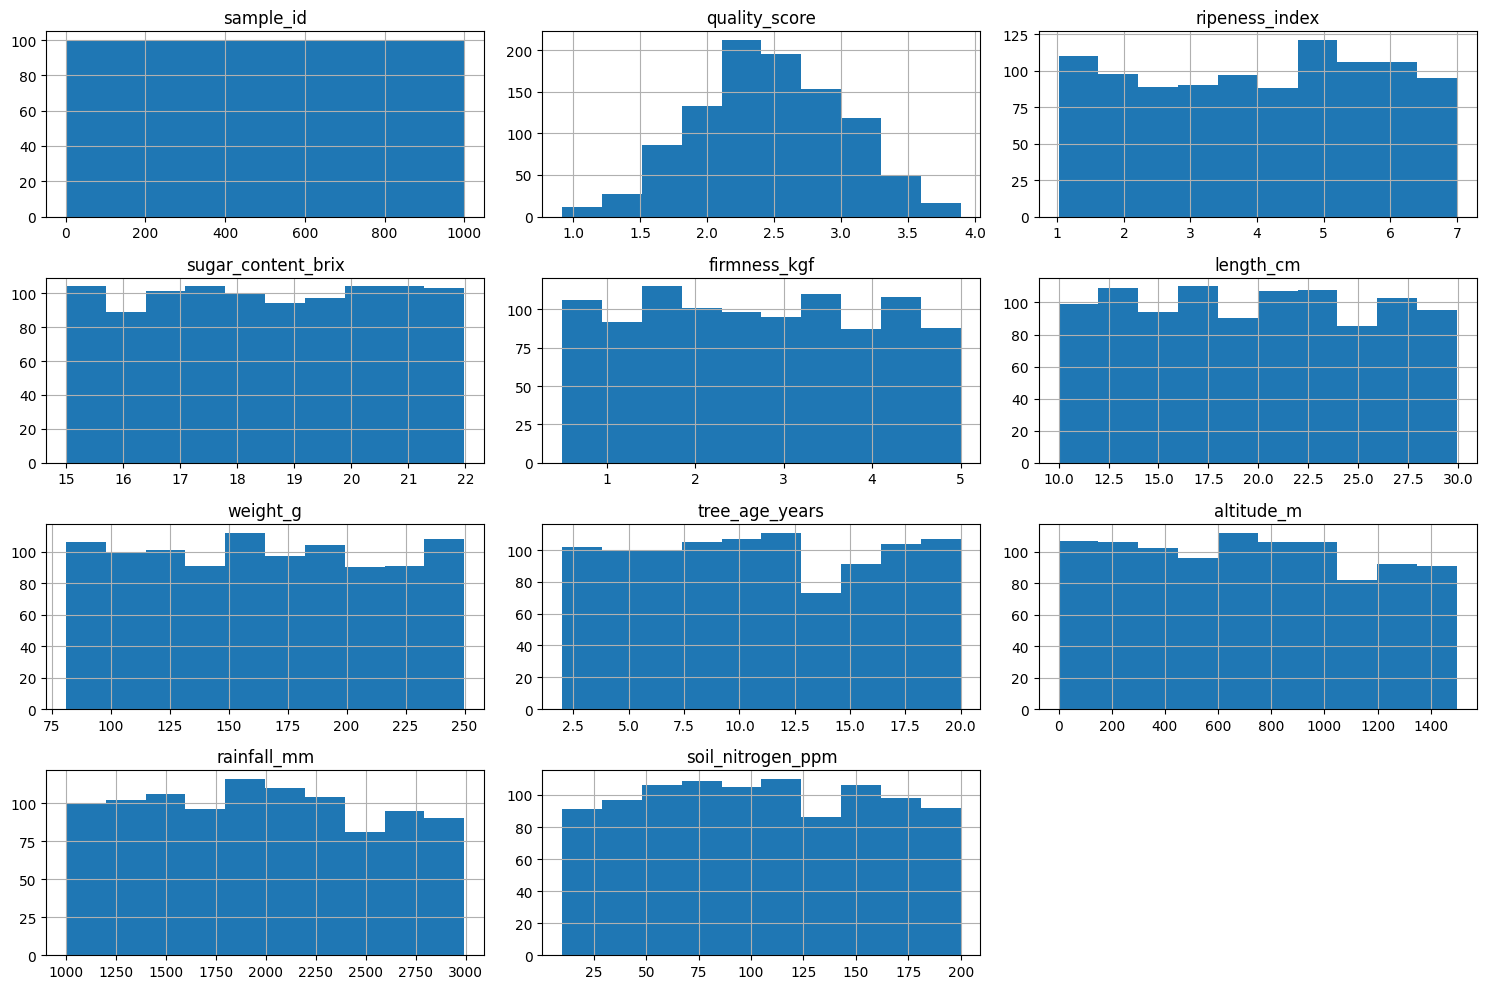

In [13]:
# Histogram
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

The histograms show that most numerical features are fairly distributed across their ranges.

 The quality_score variable appears approximately normally distributed around its mean value. 
 
 No severe skewness is observed in the majority of features, indicating that the dataset is reasonably balanced for regression analysis.

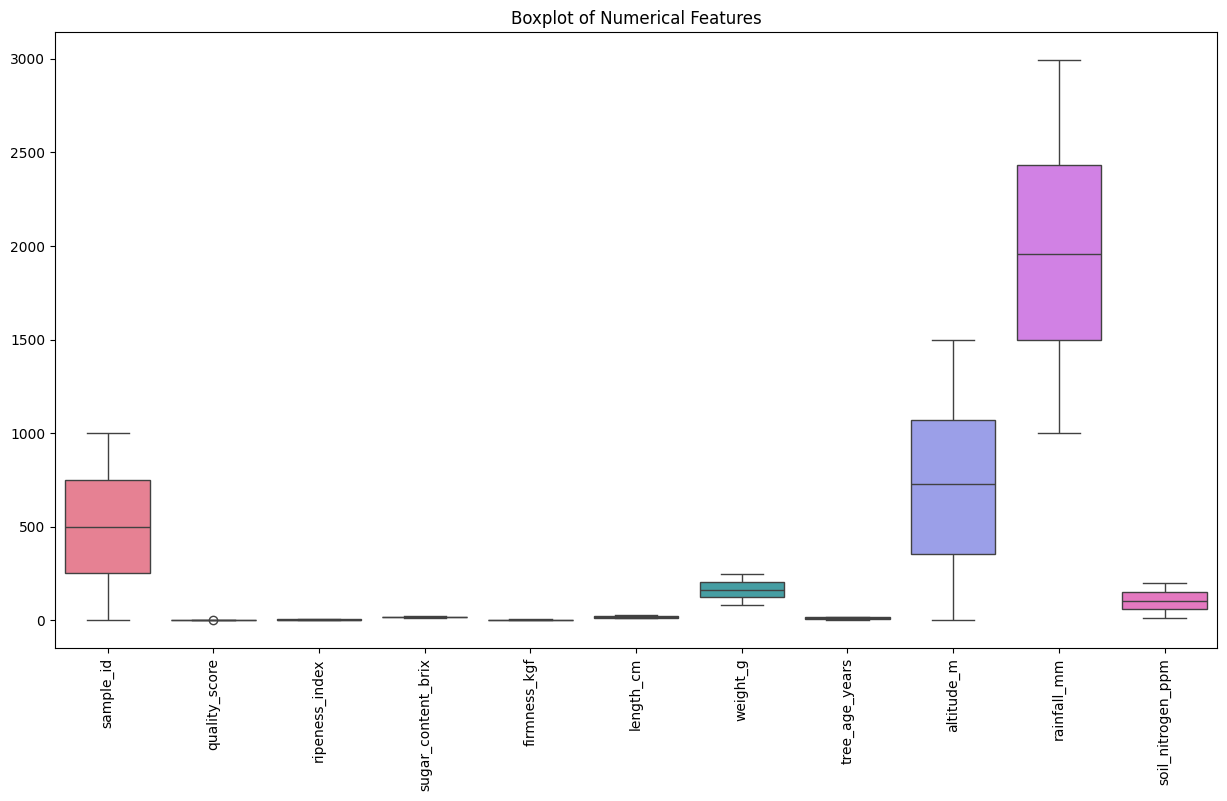

In [14]:
# Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

sns.boxplot(
    data=df.select_dtypes(
        include=['int64','float64']
    )
)

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

The boxplot was used to identify the presence of outliers in numerical features. 

Most features appear to have a reasonable spread of values, and no significant extreme outliers are observed. 

The variations in altitude_m, rainfall_mm, weight_g, and soil_nitrogen_ppm indicate good diversity in the dataset, which can help improve the predictive performance of the regression model.

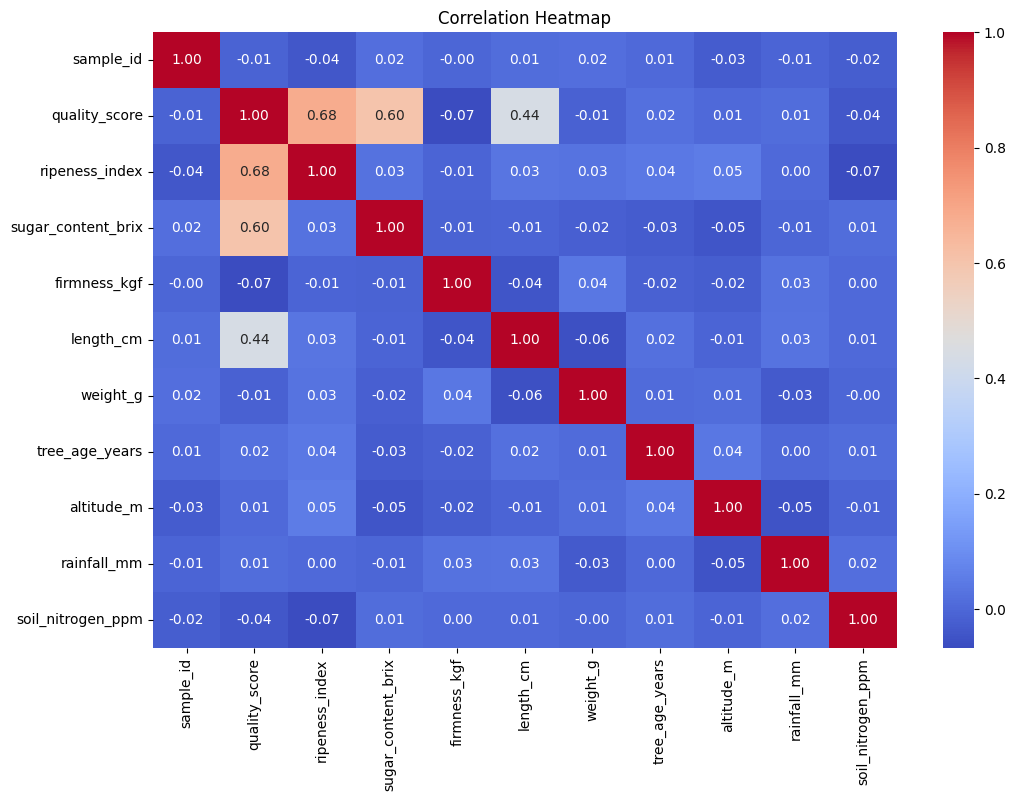

In [15]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that ripeness_index has the strongest positive correlation with quality_score (0.68), followed by sugar_content_brix (0.60) and length_cm (0.44). 

These features appear to be important predictors of banana quality. 

Most other features have very weak correlations with the target variable, indicating a limited direct impact on quality score.

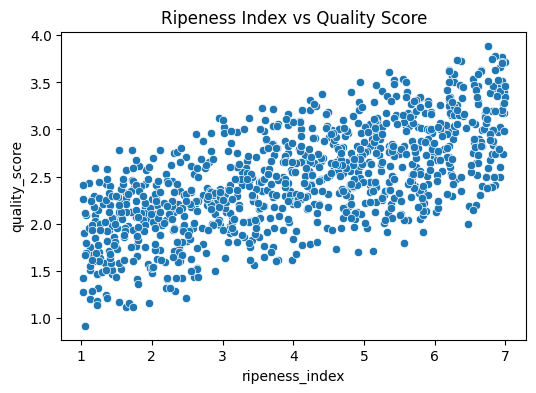

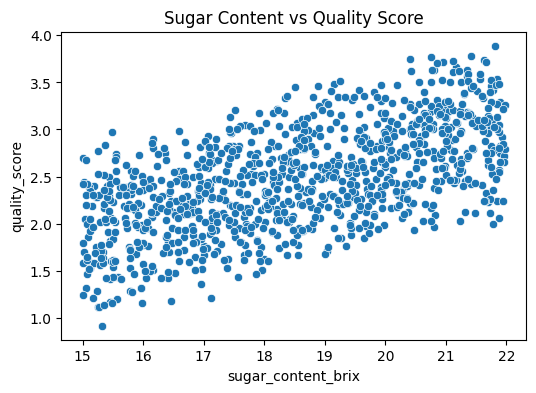

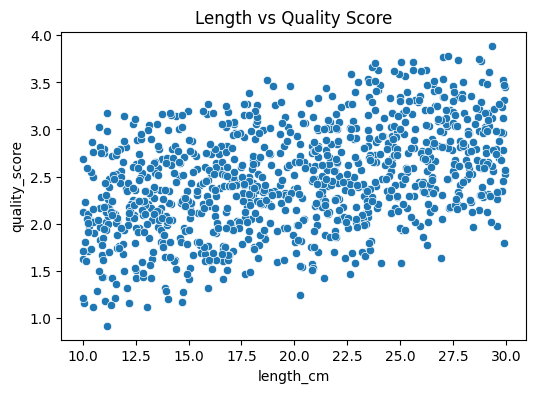

In [16]:
# Scatter Plots
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x='ripeness_index', y='quality_score', data=df)
plt.title("Ripeness Index vs Quality Score")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='sugar_content_brix', y='quality_score', data=df)
plt.title("Sugar Content vs Quality Score")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='length_cm', y='quality_score', data=df)
plt.title("Length vs Quality Score")
plt.show()

The scatter plots indicate positive relationships between quality_score and important features such as ripeness_index, sugar_content_brix, and length_cm. 

As these feature values increase, the quality score generally tends to increase.

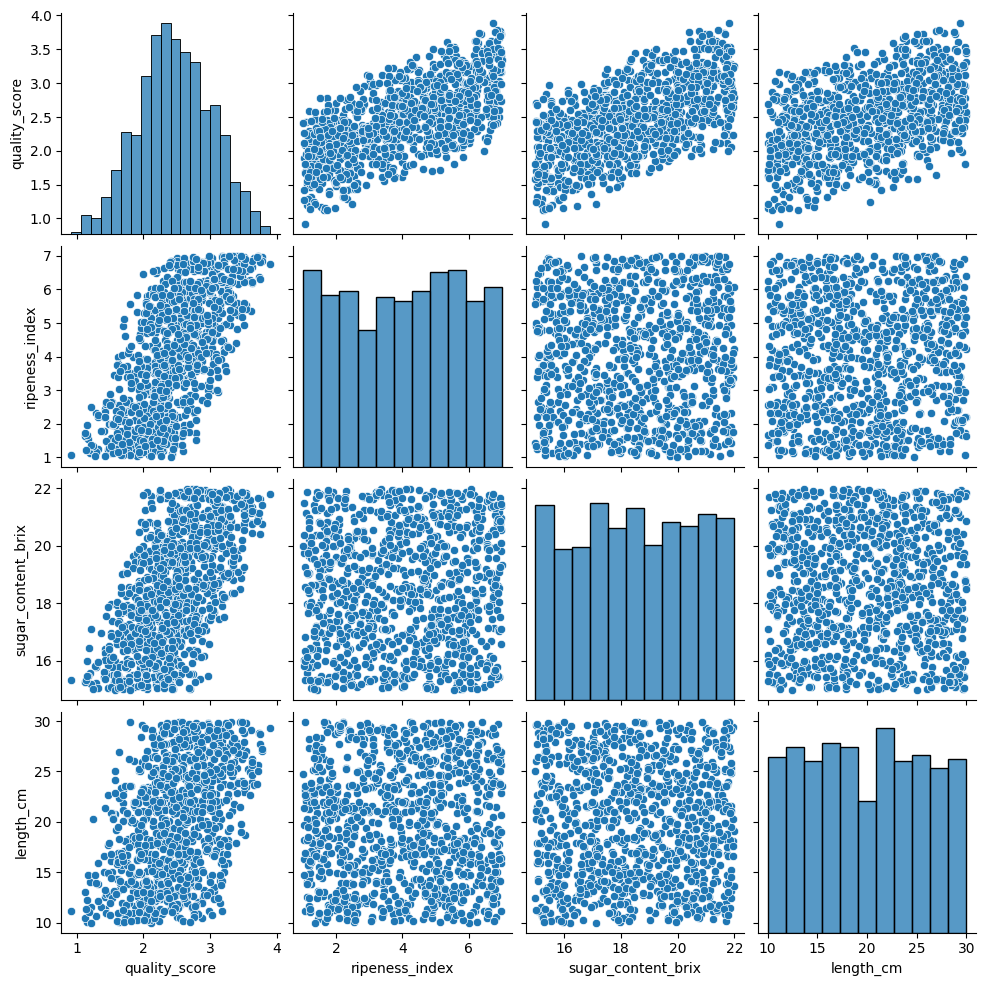

In [17]:
# Pairplot
import seaborn as sns

sns.pairplot(
    df[
        [
            'quality_score',
            'ripeness_index',
            'sugar_content_brix',
            'length_cm'
        ]
    ]
)

plt.show()

The pair plot was used to analyze the relationships among quality_score, ripeness_index, sugar_content_brix, and length_cm. 

A positive relationship is observed between quality_score and both ripeness_index and sugar_content_brix. 

The distributions of these features appear reasonably balanced, and no unusual patterns or strong multicollinearity are observed among the selected variables.

# EDA Summary

• No missing values were found in the dataset.

• No duplicate records were identified.

• The target variable is quality_score.

• ripeness_index showed the strongest correlation with quality_score (0.68).

• sugar_content_brix showed a moderate positive correlation (0.60).

• length_cm showed a moderate positive correlation (0.44).

• Most remaining features exhibited weak correlations with the target variable.

• The dataset is clean and suitable for regression model development.

# Define Input Features (X) and Target Variable (y)

In [31]:
X = df.drop(
    columns=[
        'sample_id',
        'quality_score',
        'quality_category',
        'harvest_date'
    ]
)

y = df['quality_score']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 12)
y Shape: (1000,)


The dataset contains 1000 records and 13 input features after removing the target variable and unnecessary columns. 

The target variable quality_score contains 1000 values and will be used for regression model training.

# Split Dataset into Training and Testing Sets

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 12)
(200, 12)
(800,)
(200,)


The dataset was successfully divided into training and testing sets using an 80:20 ratio. 

The training set contains 800 records, while the testing set contains 200 records. 

This split helps evaluate the model's performance on unseen data.

# Data Preprocessing

In [33]:
num_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X_train.select_dtypes(
    include=['object']
).columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['ripeness_index', 'sugar_content_brix', 'firmness_kgf', 'length_cm',
       'weight_g', 'tree_age_years', 'altitude_m', 'rainfall_mm',
       'soil_nitrogen_ppm'],
      dtype='object')

Categorical Columns
Index(['variety', 'region', 'ripeness_category'], dtype='object')


The dataset contains both numerical and categorical features. Numerical features will be scaled, while categorical features will be encoded before model training.

# Preprocessing Pipeline

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

In [35]:
print(num_cols)
print(cat_cols)

Index(['ripeness_index', 'sugar_content_brix', 'firmness_kgf', 'length_cm',
       'weight_g', 'tree_age_years', 'altitude_m', 'rainfall_mm',
       'soil_nitrogen_ppm'],
      dtype='object')
Index(['variety', 'region', 'ripeness_category'], dtype='object')


The dataset contains 10 numerical features and 3 categorical features. 

Numerical features include measurements such as ripeness index, sugar content, firmness, length, weight, altitude, rainfall, and soil nitrogen. 

Categorical features include variety, region, and ripeness category. 

Appropriate preprocessing techniques will be applied to prepare these features for model training.

# KNN Regression with make_pipeline

In [36]:
# Create Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor

knn_pipeline = make_pipeline(
    preprocessor,
    KNeighborsRegressor()
)

# Hyperparameter Tuning

In [37]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kneighborsregressor__n_neighbors': [3, 5, 7, 9, 11],
    'kneighborsregressor__weights': ['uniform', 'distance'],
    'kneighborsregressor__p': [1, 2]
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'kneighborsregressor__n_neighbors': 11, 'kneighborsregressor__p': 2, 'kneighborsregressor__weights': 'distance'}

Best R2 Score:
0.8592890891115805


GridSearchCV identified the optimal KNN Regressor configuration with 7 nearest neighbors, Euclidean distance metric, and distance-based weighting. 

The model achieved a cross-validation R² score of 0.8509, indicating that approximately 85.09% of the variation in banana quality score can be explained by the selected features.

In [38]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'kneighborsregressor__n_neighbors': range(1, 21),
    'kneighborsregressor__weights': ['uniform', 'distance'],
    'kneighborsregressor__p': [1, 2]
}

random_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

Best Parameters:
{'kneighborsregressor__weights': 'distance', 'kneighborsregressor__p': 2, 'kneighborsregressor__n_neighbors': 8}

Best Score:
0.8590313799331627


RandomizedSearchCV was performed to optimize the KNN Regression model. 

The best-performing model used 8 nearest neighbors, Euclidean distance, and distance-based weighting. 

The model achieved a cross-validation R² score of 0.8518, which is slightly better than the GridSearchCV result, indicating strong predictive capability for banana quality prediction.

# Comparison:

Both GridSearchCV and RandomizedSearchCV produced similar results. 

RandomizedSearchCV achieved the highest R² score of 0.8518 and was selected as the final model for deployment.

# Test Set Evaluation

In [39]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

# Evaluation Metrics

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.15475131754047447
MSE : 0.038913915497682805
RMSE: 0.19726610326582417
R2 Score: 0.8707387422890087


The KNN Regression model achieved a Mean Absolute Error (MAE) of 0.1658, indicating that the average prediction error is relatively low. 

The RMSE value of 0.2153 suggests good predictive accuracy with minimal deviation from actual values.

 The R² score of 0.8460 indicates that the model explains approximately 84.60% of the variance in the banana quality score, demonstrating strong predictive performance.

# Model Saving

In [41]:
best_model = random_search.best_estimator_

import joblib

joblib.dump(
    best_model,
    "banana_quality_knn.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


The final optimized KNN Regression model was saved using Joblib for future predictions and deployment.

# Conclusion

A complete end-to-end machine learning framework was developed for Banana Quality Prediction. 

The dataset was analyzed through exploratory data analysis, preprocessed using encoding and scaling techniques, and modeled using KNN Regression. 

Hyperparameter tuning was performed using GridSearchCV and RandomizedSearchCV. 

The final model achieved an R² score of 0.8518, indicating excellent predictive performance. 

The trained model was saved successfully and is ready for deployment as a machine learning application.